 CÂY KHUNG NHỎ NHẤT (Minimum Spanning Tree - MST)

## 1. Khái niệm cơ bản

### 📌 Đồ thị (Graph)
- Đồ thị \( G = (V, E) \)
  - \( V \): tập đỉnh (vertices)
  - \( E \): tập cạnh (edges)
- Đồ thị có trọng số: mỗi cạnh có một giá trị (weight)

---

### Cây (Tree)
- Là đồ thị:
  - Liên thông
  - Không có chu trình

**Tính chất:**
- Nếu có \( n \) đỉnh thì có \( n - 1 \) cạnh

---

### 🌳 Cây khung (Spanning Tree)
- Là cây con của đồ thị:
  - Chứa tất cả các đỉnh
  - Không có chu trình

---

## 2. Cây khung nhỏ nhất (MST)

### 📌 Định nghĩa
Cây khung nhỏ nhất (Minimum Spanning Tree - MST) là:
- Một cây khung của đồ thị
- Có tổng trọng số các cạnh là nhỏ nhất

### 📌 Công thức
\[
MST = \min \sum_{(u,v) \in T} w(u,v)
\]

---

## 3. Tính chất của MST

### ✅ Không có chu trình
- MST luôn là một cây → không có chu trình

### ✅ Số cạnh
- Với \( n \) đỉnh:
\[
|E| = n - 1
\]

### ✅ Tối ưu cục bộ
- Chọn cạnh nhỏ nhất mà không tạo chu trình sẽ dẫn đến nghiệm tối ưu

### ✅ Có thể có nhiều MST
- Nếu có nhiều cạnh cùng trọng số

---

## 4. Thuật toán tìm MST

## 🔥 4.1 Thuật toán Prim

### 📌 Ý tưởng
- Bắt đầu từ một đỉnh bất kỳ
- Mỗi bước chọn cạnh nhỏ nhất nối từ cây hiện tại ra ngoài

### 📌 Các bước
1. Chọn đỉnh bắt đầu
2. Đưa vào tập đã chọn
3. Lặp:
   - Chọn cạnh nhỏ nhất nối tới đỉnh chưa xét
4. Dừng khi có đủ \( n - 1 \) cạnh

### 📌 Độ phức tạp
- \( O(E \log V) \)

---

## 🔥 4.2 Thuật toán Kruskal

### 📌 Ý tưởng
- Chọn cạnh nhỏ nhất trong toàn bộ đồ thị

### 📌 Các bước
1. Sắp xếp các cạnh theo trọng số tăng dần
2. Duyệt từng cạnh:
   - Nếu không tạo chu trình → chọn
3. Dừng khi đủ \( n - 1 \) cạnh

### 📌 Kiểm tra chu trình
- Sử dụng Union-Find (Disjoint Set)

### 📌 Độ phức tạp
- \( O(E \log E) \)

---

## 5. So sánh Prim và Kruskal

| Tiêu chí | Prim | Kruskal |
|--------|------|--------|
| Cách chọn | từ 1 đỉnh | theo cạnh |
| Cấu trúc dữ liệu | priority queue | union-find |
| Phù hợp | đồ thị dày | đồ thị thưa |

---

## 6. Ứng dụng

- Thiết kế mạng (internet, điện)
- Xây dựng hệ thống đường đi tối ưu
- Phân cụm dữ liệu (clustering)
- Tối ưu chi phí kết nối

---

## 7. Phân biệt MST và Shortest Path

| MST | Shortest Path |
|-----|--------------|
| Tổng trọng số toàn cây nhỏ nhất | Đường đi từ A đến B nhỏ nhất |
| Không cần đỉnh bắt đầu | Có đỉnh bắt đầu |
| Tối ưu toàn cục | Tối ưu cục bộ |

---

## 🎯 Kết luận
- MST là bài toán tối ưu trên đồ thị
- Hai thuật toán quan trọng:
  - Prim
  - Kruskal
- Dựa trên nguyên lý tham lam (Greedy)

In [1]:
# ===============================
# GRAPH STRUCTURE (Adjacency List)
# ===============================
# graph[u] = [(v, weight), ...]

graph = {
    0: [(1, 4), (2, 3)],
    1: [(0, 4), (2, 1), (3, 2)],
    2: [(0, 3), (1, 1), (3, 4)],
    3: [(1, 2), (2, 4)]
}

In [2]:
#prim
import heapq

def prim(graph, start=0):
    visited = set([start])
    edges = []
    
    for v, w in graph[start]:
        edges.append((w, start, v))
    
    heapq.heapify(edges)
    mst = []
    total_weight = 0

    while edges:
        w, u, v = heapq.heappop(edges)
        
        if v not in visited:
            visited.add(v)
            mst.append((u, v, w))
            total_weight += w

            for to, weight in graph[v]:
                if to not in visited:
                    heapq.heappush(edges, (weight, v, to))

    return mst, total_weight


mst_prim, w_prim = prim(graph)
print("Prim MST:", mst_prim)
print("Total weight:", w_prim)

Prim MST: [(0, 2, 3), (2, 1, 1), (1, 3, 2)]
Total weight: 6


In [3]:
#kruskal
def find(parent, x):
    if parent[x] != x:
        parent[x] = find(parent, parent[x])
    return parent[x]

def union(parent, rank, x, y):
    rx = find(parent, x)
    ry = find(parent, y)

    if rx != ry:
        if rank[rx] < rank[ry]:
            parent[rx] = ry
        else:
            parent[ry] = rx
            if rank[rx] == rank[ry]:
                rank[rx] += 1

def kruskal(graph):
    edges = []
    
    # chuyển graph -> edge list
    for u in graph:
        for v, w in graph[u]:
            if u < v:  # tránh trùng cạnh
                edges.append((u, v, w))
    
    edges.sort(key=lambda x: x[2])

    parent = {node: node for node in graph}
    rank = {node: 0 for node in graph}

    mst = []
    total_weight = 0

    for u, v, w in edges:
        if find(parent, u) != find(parent, v):
            union(parent, rank, u, v)
            mst.append((u, v, w))
            total_weight += w

    return mst, total_weight


mst_kruskal, w_kruskal = kruskal(graph)
print("Kruskal MST:", mst_kruskal)
print("Total weight:", w_kruskal)

Kruskal MST: [(1, 2, 1), (1, 3, 2), (0, 2, 3)]
Total weight: 6


In [4]:
#3. DIJKSTRA (Shortest Path)
import heapq

def dijkstra(graph, start):
    dist = {node: float('inf') for node in graph}
    dist[start] = 0

    pq = [(0, start)]

    while pq:
        d, u = heapq.heappop(pq)

        if d > dist[u]:
            continue

        for v, w in graph[u]:
            if dist[v] > dist[u] + w:
                dist[v] = dist[u] + w
                heapq.heappush(pq, (dist[v], v))

    return dist


distances = dijkstra(graph, 0)
print("Shortest paths from 0:", distances)

Shortest paths from 0: {0: 0, 1: 4, 2: 3, 3: 6}


In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# ===============================
# TẠO ĐỒ THỊ
# ===============================
G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,4),
    (0,2,3),
    (1,2,1),
    (1,3,2),
    (2,3,4)
])
mst = nx.minimum_spanning_tree(G, algorithm='prim')

print("MST edges:", list(mst.edges(data=True)))

MST edges: [(0, 2, {'weight': 3}), (1, 2, {'weight': 1}), (1, 3, {'weight': 2})]


In [6]:
mst_k = nx.minimum_spanning_tree(G, algorithm='kruskal')
print("MST edges:", list(mst_k.edges(data=True)))

MST edges: [(0, 2, {'weight': 3}), (1, 2, {'weight': 1}), (1, 3, {'weight': 2})]


In [7]:
# khoảng cách từ node 0
dist = nx.single_source_dijkstra_path_length(G, 0)

print("Shortest distances:", dist)

# đường đi cụ thể
path = nx.single_source_dijkstra_path(G, 0)
print("Paths:", path)

Shortest distances: {0: 0, 2: 3, 1: 4, 3: 6}
Paths: {0: [0], 1: [0, 1], 2: [0, 2], 3: [0, 1, 3]}


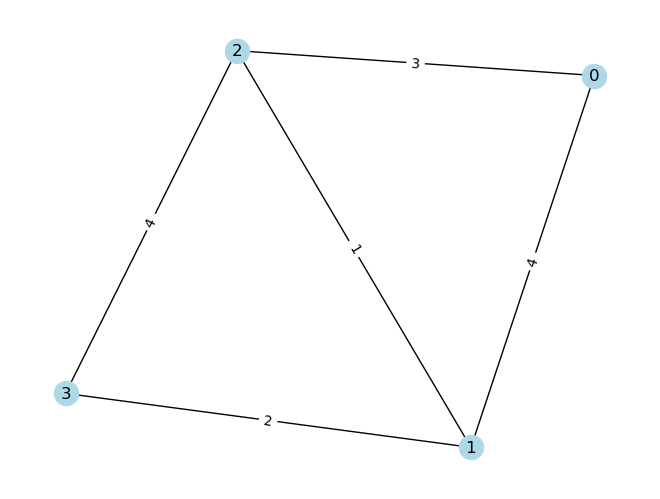

In [8]:
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.show()